<a href="https://colab.research.google.com/github/juborduchi/governanca-digital_mre/blob/main/relatorio-gestao-mre/relatorio_gestao2024.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

# Exemplo de como o caminho pode ficar após montar o Drive.
# Ajuste 'Meu Drive/sua_pasta_com_pdfs' para o caminho real da sua pasta no Google Drive.
# Por exemplo, se seus PDFs estiverem em 'Meu Drive/Documentos/Meus_PDFs', o caminho seria '/content/drive/MyDrive/Documentos/Meus_PDFs'
pdf_directory_in_drive = '/content/drive/MyDrive/relatorio-gestao-MRE/Relatorio-Gestao-MRE-2024.pdf' # <--- ALtere ESTE CAMINHO para o caminho COMPLETO do seu arquivo PDF!

print(f"O Google Drive foi montado. Por favor, verifique se o caminho '{pdf_directory_in_drive}' aponta para a sua pasta de PDFs correta.")

Mounted at /content/drive
O Google Drive foi montado. Por favor, verifique se o caminho '/content/drive/MyDrive/relatorio-gestao-MRE/Relatorio-Gestao-MRE-2024.pdf' aponta para a sua pasta de PDFs correta.


In [3]:
!pip install PyPDF2

import os
from PyPDF2 import PdfReader

def extract_text_from_pdf(pdf_path):
    """
    Extrai texto de um arquivo PDF.
    """
    text = ""
    try:
        with open(pdf_path, 'rb') as file:
            reader = PdfReader(file)
            for page in reader.pages:
                text += page.extract_text() or ""
    except Exception as e:
        print(f"Erro ao extrair texto de {pdf_path}: {e}")
    return text

# --- EXECUTANDO A EXTRAÇÃO DE TEXTO ---
# Usaremos a variável 'pdf_directory_in_drive' definida após a montagem do Google Drive
# Lembre-se de que essa variável deve conter o CAMINHO COMPLETO DO ARQUIVO PDF, e não apenas o diretório.
pdf_file_path = pdf_directory_in_drive # <--- Este é o caminho completo para o seu PDF específico

extracted_pdf_texts = {}
if os.path.exists(pdf_file_path):
    print(f"Extraindo texto de: {os.path.basename(pdf_file_path)}")
    text = extract_text_from_pdf(pdf_file_path)
    if text:
        extracted_pdf_texts[os.path.basename(pdf_file_path)] = text
        print(f"Texto extraído do arquivo PDF: {os.path.basename(pdf_file_path)}")
        # Para visualizar um trecho do texto:
        print(f"\nConteúdo (trecho):\n{text[:500]}...")
    else:
        print(f"Nenhum texto foi extraído do arquivo '{pdf_file_path}'. Verifique se é um PDF válido e não está vazio.")
else:
    print(f"O arquivo PDF '{pdf_file_path}' não foi encontrado. Por favor, verifique o caminho completo e o nome do arquivo.")

# A variável 'extracted_pdf_texts' agora contém um dicionário com o texto do PDF.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 1.6 MB/s eta 0:00:00
Extraindo texto de: Relatorio-Gestao-MRE-2024.pdf
Texto extraído do arquivo PDF: Relatorio-Gestao-MRE-2024.pdf

Conteúdo (trecho):
  
 
 
 
  
 
RELATÓRIO DE GESTÃO INTEGRADO DO MINIST ÉRIO DAS 
RELAÇÕES EXTERIORES (MRE) 202 4 
 
Embaixador Mauro Vieira  
Ministro de Estado das Relações Exteriores  
 
Embaixadora Maria Laura da Rocha  
Secretária -Geral das Relações Exteriores  
 
Embaixador Denis Fontes de Souza Pinto  
Secretário de Gestão Administrativa  
 
Embaixador Carlos Sérgio Sobral Duarte  
Secretário de África e de Oriente Médio  
 
Embaixador André  Aranha Corrêa do Lago  
Secretário de Clima, Energia e Meio Amb...


## 2. Pré-processamento de Texto

Agora que o texto foi extraído dos PDFs, o próximo passo é realizar o pré-processamento. Isso inclui:

*   **Limpeza**: Remover caracteres especiais, números e pontuações.
*   **Normalização**: Converter todo o texto para minúsculas.
*   **Tokenização**: Dividir o texto em palavras (tokens).
*   **Remoção de Stop Words**: Remover palavras comuns que não adicionam muito significado (como 'e', 'o', 'a', etc.).
*   **Lematização/Radicalização (Opcional)**: Reduzir as palavras à sua forma base para unificar termos semelhantes (ex: 'correndo', 'corre' -> 'correr').

Vou adicionar uma célula com o código para realizar estas etapas. Para isso, vamos usar a biblioteca `nltk`.

In [4]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import re

# Baixar recursos do NLTK (diretamente, sem try-except complexo para DownloadError)
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt_tab', quiet=True) # Adicionado para corrigir o erro de tokenização em português

# Defina as stop words em português
stop_words = set(stopwords.words('portuguese'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    """
    Realiza o pré-processamento de um texto:
    - Converte para minúsculas.
    - Remove caracteres não alfabéticos e números.
    - Tokeniza o texto.
    - Remove stop words.
    - Lematiza as palavras (opcional).
    """
    text = text.lower() # Converter para minúsculas
    # Manter apenas letras (incluindo acentuadas para português) e espaços
    text = re.sub(r'[^a-záàâãéêíóôõúüç\s]', '', text)
    tokens = word_tokenize(text, language='portuguese') # Tokenizar
    tokens = [word for word in tokens if word not in stop_words] # Remover stop words
    # tokens = [lemmatizer.lemmatize(word) for word in tokens] # Lematização (opcional, requer stopwords em ingles)
    return ' '.join(tokens)

# Aplica o pré-processamento a todos os textos extraídos
if 'extracted_pdf_texts' in locals() and extracted_pdf_texts:
    processed_texts = {
        filename: preprocess_text(text)
        for filename, text in extracted_pdf_texts.items()
    }
    print("Textos pré-processados com sucesso!")
    # Para visualizar um trecho do texto pré-processado do primeiro arquivo:
    first_pdf_name = list(processed_texts.keys())[0]
    print(f"\nPrimeiro PDF Processado: {first_pdf_name}\nConteúdo (trecho):\n{processed_texts[first_pdf_name][:500]}...")
else:
    print("Não há textos extraídos para pré-processar. Por favor, execute a etapa anterior primeiro.")

# A variável 'processed_texts' agora contém um dicionário com os textos pré-processados.

Textos pré-processados com sucesso!

Primeiro PDF Processado: Relatorio-Gestao-MRE-2024.pdf
Conteúdo (trecho):
relatório gestão integrado minist ério relações exteriores mre embaixador mauro vieira ministro estado relações exteriores embaixadora maria laura rocha secretária geral relações exteriores embaixador denis fontes souza pinto secretário gestão administrativa embaixador carlos sérgio sobral duarte secretário áfrica oriente médio embaixador andré aranha corrêa lago secretário clima energia meio ambiente embaixadora maria luisa escorel moraes secretária europa américa norte embaixador carlos márcio...


## 3. Geração de Embeddings Semânticos

Com o texto limpo e tokenizado, o próximo passo fundamental é converter esse texto em representações numéricas densas, conhecidas como **embeddings semânticos**. Esses embeddings capturam o significado contextual das palavras e frases, permitindo que a similaridade semântica seja calculada matematicamente.

Utilizaremos a biblioteca `sentence-transformers` que oferece modelos pré-treinados eficientes para gerar embeddings de frases e documentos. Para o português, um modelo como `"distiluse-base-multilingual-cased-v2"` ou `"paraphrase-multilingual-MiniLM-L12-v2"` pode ser uma boa escolha.

Esta etapa irá:

1.  Instalar a biblioteca `sentence-transformers`.
2.  Carregar um modelo pré-treinado.
3.  Gerar embeddings para cada um dos documentos pré-processados.

In [5]:
!pip install sentence-transformers

from sentence_transformers import SentenceTransformer

# Carregar um modelo pré-treinado multilíngue
# 'distiluse-base-multilingual-cased-v2' é uma boa opção para vários idiomas, incluindo português.
# 'paraphrase-multilingual-MiniLM-L12-v2' é outra alternativa leve e eficiente.
model_name = 'distiluse-base-multilingual-cased-v2'
# model_name = 'paraphrase-multilingual-MiniLM-L12-v2'

try:
    print(f"Carregando o modelo Sentence Transformer: {model_name}")
    model = SentenceTransformer(model_name)
    print("Modelo carregado com sucesso!")
except Exception as e:
    print(f"Erro ao carregar o modelo {model_name}: {e}")
    print("Verifique sua conexão com a internet ou tente um modelo diferente.")
    model = None

if model and 'processed_texts' in locals() and processed_texts:
    # Extrair os textos pré-processados para gerar embeddings
    document_names = list(processed_texts.keys())
    documents = [processed_texts[name] for name in document_names]

    print(f"Gerando embeddings para {len(documents)} documentos...")
    document_embeddings = model.encode(documents, show_progress_bar=True)
    print("Embeddings gerados com sucesso!")

    # Armazenar os embeddings em um dicionário para fácil acesso
    # (ou você pode manter como um array numpy e mapear pelos índices)
    embeddings_dict = {name: embedding for name, embedding in zip(document_names, document_embeddings)}

    print(f"Exemplo do formato de um embedding (primeiro documento):\n{embeddings_dict[document_names[0]][:10]}...")
    print(f"Dimensão dos embeddings: {document_embeddings.shape[1]}")
else:
    print("Não foi possível gerar embeddings. Certifique-se de que o modelo foi carregado e os textos foram pré-processados.")

# A variável 'embeddings_dict' contém os embeddings para cada documento.

Carregando o modelo Sentence Transformer: distiluse-base-multilingual-cased-v2


modules.json:   0%|          | 0.00/341 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/2.46k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

2_Dense/model.safetensors: reconstructing file:   0%|          |  0.00B / 1.58MB            

2_Dense/model.safetensors: downloading bytes:           |  0.00B            

Modelo carregado com sucesso!
Gerando embeddings para 1 documentos...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Embeddings gerados com sucesso!
Exemplo do formato de um embedding (primeiro documento):
[ 0.04234737  0.0136814  -0.00029797 -0.02256332 -0.04951209 -0.05755052
 -0.00480021 -0.01454923  0.04582771  0.03046588]...
Dimensão dos embeddings: 512


## 4. Definição de Termos e Cálculo de Similaridade Semântica

Agora que temos os embeddings para os documentos, precisamos definir os termos para os quais queremos calcular a similaridade. Isso inclui o termo central e os dois conjuntos de termos que representam as abordagens que você deseja comparar.

Esta etapa irá:

1.  Definir o termo central e os dois conjuntos de termos (Abordagem A e Abordagem B).
2.  Gerar embeddings para esses termos usando o mesmo modelo `SentenceTransformer`.
3.  Calcular a similaridade de cosseno entre o termo central e cada termo nos conjuntos A e B. A similaridade de cosseno mede o ângulo entre dois vetores, onde um valor mais próximo de 1 indica maior similaridade.

**Atenção**: Você precisará editar a célula de código abaixo para inserir o seu `termo_central` e os termos para `abordagem_A_termos` e `abordagem_B_termos`.

In [6]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# --- DEFINA SEUS TERMOS AQUI ---
# Por favor, substitua pelos seus termos reais
termo_central = "internet"

abordagem_A_termos = [
    "multilaterais",
    "multissetoriais",
    "governança",
    "democrática",
    "soberania"
]
abordagem_B_termos = [
   "autorregulação",
    "inovação",
    "desenvolvimento",
    "mercado",
    "investimento",
]

# Combine todos os termos para gerar embeddings de uma vez
all_comparison_terms = [termo_central] + abordagem_A_termos + abordagem_B_termos

if 'model' in locals() and model:
    print("Gerando embeddings para os termos de comparação...")
    comparison_embeddings = model.encode(all_comparison_terms, show_progress_bar=True)
    print("Embeddings dos termos de comparação gerados com sucesso!")

    # Separar os embeddings
    central_embedding = comparison_embeddings[0].reshape(1, -1)
    abordagem_A_embeddings = comparison_embeddings[1 : 1 + len(abordagem_A_termos)]
    abordagem_B_embeddings = comparison_embeddings[1 + len(abordagem_A_termos) :]

    # --- CALCULAR SIMILARIDADE PARA ABORDAGEM A ---
    print(f"\nCalculando similaridade para a Abordagem A (Termo Central: '{termo_central}')")
    similarity_A = cosine_similarity(central_embedding, abordagem_A_embeddings)[0]

    results_A = []
    for i, term in enumerate(abordagem_A_termos):
        results_A.append({"termo": term, "similaridade": similarity_A[i]})
        print(f"  - {term}: {similarity_A[i]:.4f}")

    # --- CALCULAR SIMILARIDADE PARA ABORDAGEM B ---
    print(f"\nCalculando similaridade para a Abordagem B (Termo Central: '{termo_central}')")
    similarity_B = cosine_similarity(central_embedding, abordagem_B_embeddings)[0]

    results_B = []
    for i, term in enumerate(abordagem_B_termos):
        results_B.append({"termo": term, "similaridade": similarity_B[i]})
        print(f"  - {term}: {similarity_B[i]:.4f}")

    print("\nSimilaridades calculadas com sucesso!")

    # Você pode agora usar 'results_A' e 'results_B' para análise e visualização.
    # Por exemplo, para obter a similaridade média:
    avg_similarity_A = np.mean([res['similaridade'] for res in results_A])
    avg_similarity_B = np.mean([res['similaridade'] for res in results_B])

    print(f"\nSimilaridade Média Abordagem A: {avg_similarity_A:.4f}")
    print(f"Similaridade Média Abordagem B: {avg_similarity_B:.4f}")

else:
    print("O modelo de embeddings não foi carregado ou não está disponível. Por favor, verifique a etapa anterior.")


# As variáveis 'results_A' e 'results_B' contêm as similaridades calculadas.


Gerando embeddings para os termos de comparação...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Embeddings dos termos de comparação gerados com sucesso!

Calculando similaridade para a Abordagem A (Termo Central: 'internet')
  - multilaterais: 0.2446
  - multissetoriais: 0.3296
  - governança: 0.3530
  - democrática: 0.3158
  - soberania: 0.3459

Calculando similaridade para a Abordagem B (Termo Central: 'internet')
  - autorregulação: 0.2498
  - inovação: 0.3520
  - desenvolvimento: 0.3266
  - mercado: 0.3477
  - investimento: 0.3402

Similaridades calculadas com sucesso!

Similaridade Média Abordagem A: 0.3178
Similaridade Média Abordagem B: 0.3232


## 5. Visualização do Espaço Semântico

Para entender melhor as relações entre o termo central e os termos das abordagens A e B, podemos visualizar esses termos em um espaço semântico. Usaremos a Análise de Componentes Principais (PCA) para reduzir a dimensionalidade dos embeddings para 2D e plotá-los.

Este gráfico ajudará a identificar visualmente qual abordagem está mais próxima semanticamente do termo central.

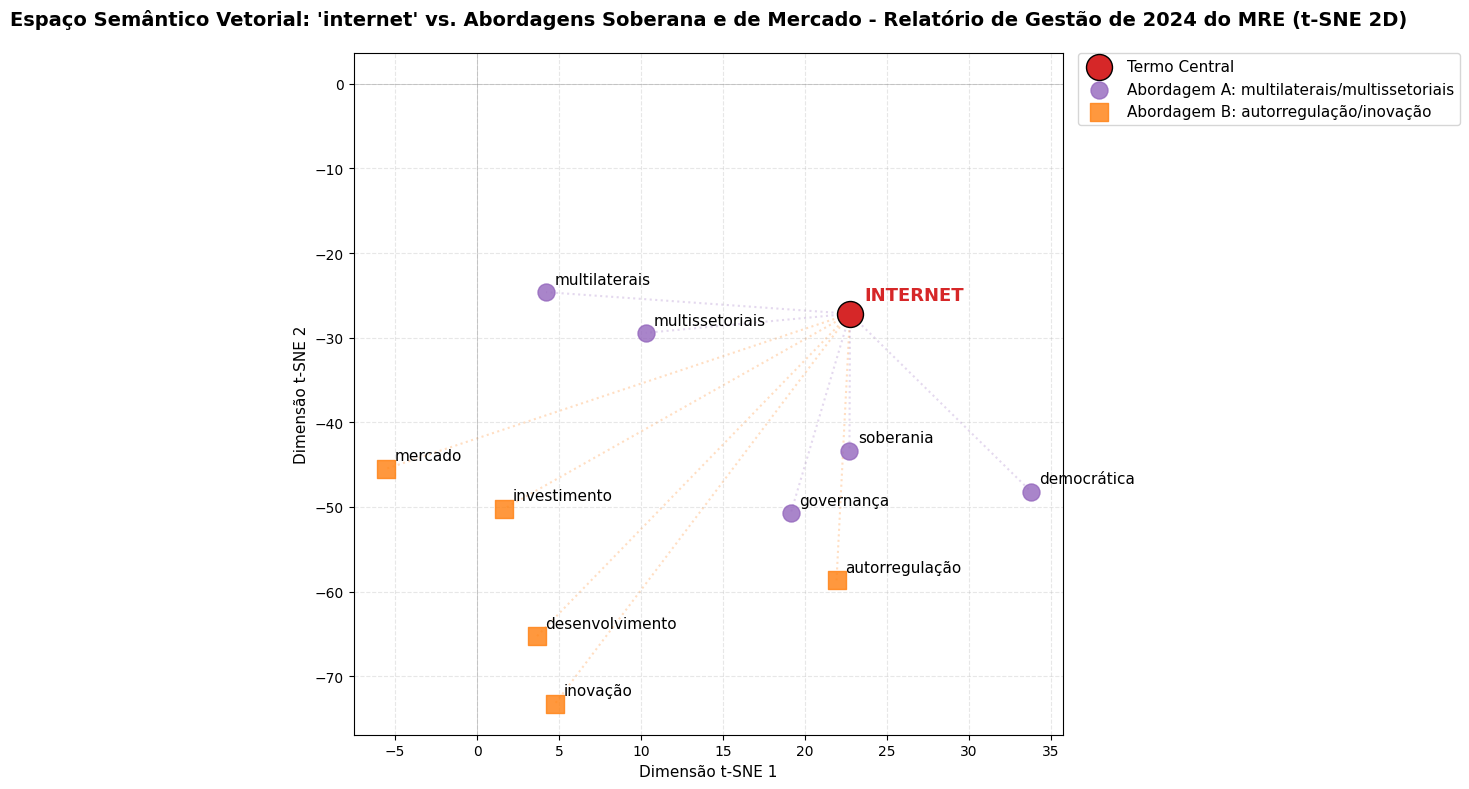

In [7]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE # Importar t-SNE
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings
import numpy as np # Adicionado explicitamente para np.vstack

# Omitir avisos de convergência do t-SNE para limpar o output
warnings.filterwarnings("ignore", category=FutureWarning)

if 'model' in locals() and model and 'central_embedding' in locals() and 'abordagem_A_embeddings' in locals() and 'abordagem_B_embeddings' in locals():
    # Mapear os termos existentes para as variáveis de conveniência do exemplo do usuário
    CONCEITO_CHAVE = termo_central
    PERSPECTIVA_MULTILATERAL = abordagem_A_termos
    PERSPECTIVA_MERCADO = abordagem_B_termos

    TODOS_CONCEITOS = [
        CONCEITO_CHAVE
    ] + PERSPECTIVA_MULTILATERAL + PERSPECTIVA_MERCADO

    # Combine todos os embeddings para a redução de dimensionalidade
    vetores = np.vstack([
        central_embedding,
        abordagem_A_embeddings,
        abordagem_B_embeddings
    ])

    # 3. Redução de Dimensionalidade com t-SNE (conforme o exemplo do usuário)
    # Perplexity deve ser menor que o número de amostras.
    perplexity_val = min(5, len(TODOS_CONCEITOS) - 1)
    if perplexity_val <= 0: # Caso haja apenas 1 termo ou nenhum, o t-SNE não funciona
        print("Não há termos suficientes para calcular t-SNE. Certifique-se de ter pelo menos 2 termos.")
    else:
        tsne = TSNE(
            n_components=2,
            perplexity=perplexity_val,
            random_state=42,
            n_iter=1000,
            learning_rate='auto', # 'auto' ou 'accelerated' são recomendados para versões recentes
            init='random' # 'random' é o padrão, mas 'pca' pode ser mais estável
        )
        coordenadas_2d = tsne.fit_transform(vetores)

        # 4. Construção do Gráfico de Dispersão (Scatter Plot) com estilo customizado
        plt.figure(figsize=(12, 8)) # Ajustado o tamanho para acomodar a legenda ao lado

        x_coords = coordenadas_2d[:, 0]
        y_coords = coordenadas_2d[:, 1]

        # Encontrar o índice do conceito chave para as linhas conectoras
        idx_conceito_chave = TODOS_CONCEITOS.index(CONCEITO_CHAVE)

        for i, palavra in enumerate(TODOS_CONCEITOS):
            if palavra == CONCEITO_CHAVE:
                plt.scatter(
                    x_coords[i],
                    y_coords[i],
                    color="#d62728", # Vermelho
                    edgecolors="black",
                    s=350,
                    zorder=5,
                    label="Termo Central"
                )
                plt.annotate(
                    palavra.upper(),
                    (x_coords[i], y_coords[i]),
                    xytext=(10, 10),
                    textcoords="offset points",
                    fontsize=13,
                    weight="bold",
                    color="#d62728",
                    ha='left'
                )

            elif palavra in PERSPECTIVA_MULTILATERAL:
                plt.scatter(
                    x_coords[i],
                    y_coords[i],
                    color="#9467bd", # Roxo
                    s=150,
                    alpha=0.8,
                    zorder=4,
                    label=(
                        "Abordagem A: " + "/".join(PERSPECTIVA_MULTILATERAL[:2])
                        if "Abordagem A: " + "/".join(PERSPECTIVA_MULTILATERAL[:2])
                        not in plt.gca().get_legend_handles_labels()[1]
                        else ""
                    ), # Garante um rótulo único na legenda
                    marker='o'
                )
                plt.annotate(
                    palavra,
                    (x_coords[i], y_coords[i]),
                    xytext=(6, 6),
                    textcoords="offset points",
                    fontsize=11,
                    ha='left'
                )
                plt.plot(
                    [x_coords[idx_conceito_chave], x_coords[i]],
                    [y_coords[idx_conceito_chave], y_coords[i]],
                    color="#9467bd", # Roxo
                    linestyle=":",
                    alpha=0.25,
                    zorder=1
                )

            elif palavra in PERSPECTIVA_MERCADO:
                plt.scatter(
                    x_coords[i],
                    y_coords[i],
                    color="#ff7f0e", # Laranja
                    s=150,
                    alpha=0.8,
                    zorder=4,
                    label=(
                        "Abordagem B: " + "/".join(PERSPECTIVA_MERCADO[:2])
                        if "Abordagem B: " + "/".join(PERSPECTIVA_MERCADO[:2])
                        not in plt.gca().get_legend_handles_labels()[1]
                        else ""
                    ), # Garante um rótulo único na legenda
                    marker='s'
                )
                plt.annotate(
                    palavra,
                    (x_coords[i], y_coords[i]),
                    xytext=(6, 6),
                    textcoords="offset points",
                    fontsize=11,
                    ha='left'
                )
                plt.plot(
                    [x_coords[idx_conceito_chave], x_coords[i]],
                    [y_coords[idx_conceito_chave], y_coords[i]],
                    color="#ff7f0e", # Laranja
                    linestyle=":",
                    alpha=0.25,
                    zorder=1
                )

        # Configurações do Espaço Vetorial
        plt.title(
            f"Espaço Semântico Vetorial: '{CONCEITO_CHAVE}' vs. Abordagens Soberana e de Mercado - Relatório de Gestão de 2024 do MRE (t-SNE 2D)",
            fontsize=14,
            fontweight="bold",
            pad=20,
        )
        plt.xlabel("Dimensão t-SNE 1", fontsize=11)
        plt.ylabel("Dimensão t-SNE 2", fontsize=11)
        plt.grid(True, linestyle="--", alpha=0.3)

        plt.axhline(0, color="gray", linewidth=0.5, alpha=0.5)
        plt.axvline(0, color="gray", linewidth=0.5, alpha=0.5)

        # ====================================================================
        # MODIFICAÇÃO: LEGENDA POSICIONADA FORA DA ÁREA ÚTIL DO GRÁFICO
        # ====================================================================
        plt.legend(
            loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=11, borderaxespad=0
        )

        plt.tight_layout()
        plt.show()

else:
    print("Não foi possível gerar o gráfico. Certifique-se de que o modelo foi carregado e os embeddings dos termos foram calculados corretamente.")
